# การทดสอบสมมติฐานเปรียบเทียบรายได้ประจำเฉลี่ยของเกษตรกร 2 กลุ่ม
## Two-Sample Z-test (Right-tailed, α = 0.05)
**แหล่งข้อมูล:** สำนักงานสถิติแห่งชาติ

---
## ขั้นตอนที่ 1 — นำเข้าไลบรารีและโหลดข้อมูล

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib import rcParams

rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

df_raw = pd.read_csv('uploads1-9-20260312-141459167.csv', encoding='utf-8-sig')
print('Shape (ก่อน clean):', df_raw.shape)
df_raw.head(3)

Shape (ก่อน clean): (7700, 11)


,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source
0,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,29549.0,บาท,NaN,สำนักงานสถิติแห่งชาติ
1,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ประจำ,รายได้ประจำ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,29549.0,บาท,NaN,สำนักงานสถิติแห่งชาติ
2,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ที่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,23925.0,บาท,NaN,สำนักงานสถิติแห่งชาติ


---
## ขั้นตอนที่ 2 — Data Cleaning

In [3]:
df = df_raw.copy()
df['value'] = pd.to_numeric(df['value'], errors='coerce')

mask = (
    (df['value'] > 0) &
    (df['source_income1'] == 'รายได้ประจำ') &
    (df['source_income2'] == 'รายได้ประจำ') &
    (df['source_income3'] == 'รายได้ประจำ')
)
df = df[mask].reset_index(drop=True)

print(f'Shape (หลัง clean) : {df.shape}')
print(f'แถวที่ถูกลบออก     : {len(df_raw) - len(df):,} แถว')
print(f'value <= 0 คงเหลือ : {(df["value"] <= 0).sum()} แถว')

Shape (หลัง clean) : (744, 11)
แถวที่ถูกลบออก     : 6,956 แถว
value <= 0 คงเหลือ : 0 แถว


---
## ขั้นตอนที่ 3 — สถิติเชิงพรรณนา (Descriptive Statistics)

In [4]:
GROUP_A = 'ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้าของที่ดิน'
GROUP_B = 'ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ดิน/ทำฟรี'

group_a = df[df['soc_eco_class2'] == GROUP_A]['value']
group_b = df[df['soc_eco_class2'] == GROUP_B]['value']

n1, n2     = len(group_a),              len(group_b)
mean1, mean2 = group_a.mean(),          group_b.mean()
sd1,   sd2   = group_a.std(ddof=1),    group_b.std(ddof=1)

desc = pd.DataFrame({
    'กลุ่ม'      : ['A — ส่วนใหญ่เป็นเจ้าของที่ดิน', 'B — ส่วนใหญ่เช่าที่ดิน/ทำฟรี'],
    'N'          : [n1,    n2],
    'Mean (บาท)' : [round(mean1, 4), round(mean2, 4)],
    'SD (บาท)'   : [round(sd1, 4),   round(sd2, 4)],
    'Min (บาท)'  : [group_a.min(),   group_b.min()],
    'Max (บาท)'  : [group_a.max(),   group_b.max()],
}).set_index('กลุ่ม')

desc

,N,Mean (บาท),SD (บาท),Min (บาท),Max (บาท)
กลุ่ม,,,,,
A — ส่วนใหญ่เป็นเจ้าของที่ดิน,76,27442.0921,14169.6258,6756.0,88207.0
B — ส่วนใหญ่เช่าที่ดิน/ทำฟรี,63,29189.3016,22783.5157,8645.0,181322.0


---
## ขั้นตอนที่ 4 — Two-Sample Z-test (Right-tailed)

**สมมติฐาน:**
- **H₀:** μ₁ − μ₂ = 0 &emsp; (รายได้เฉลี่ยกลุ่ม A = กลุ่ม B)
- **H₁:** μ₁ − μ₂ > 0 &emsp; (รายได้เฉลี่ยกลุ่ม A > กลุ่ม B)

**เกณฑ์ตัดสิน:** ปฏิเสธ H₀ ถ้า **Z > Z_critical**

**ระดับนัยสำคัญ (α):** 0.05

In [7]:
ALPHA = 0.05

# --- คำนวณ Z-statistic ---
se     = np.sqrt(sd1**2 / n1 + sd2**2 / n2)   # Standard Error of (mean1 - mean2)
z_stat = (mean1 - mean2) / se

# --- Z-critical (right-tailed) ---
z_crit = stats.norm.ppf(1 - ALPHA)             # = 1.6449

# --- ผลการทดสอบ (เปรียบ Z vs Z_critical เท่านั้น) ---
reject = z_stat > z_crit

print('=' * 52)
print('ผลการทดสอบ Two-Sample Z-test (Right-tailed)')
print('=' * 52)
print(f'Standard Error (SE) : {se:,.4f} บาท')
print(f'Z-statistic         : {z_stat:.4f}')
print(f'Z-critical (α=0.05) : {z_crit:.4f}')
print('=' * 52)
print(f'เกณฑ์: ปฏิเสธ H₀ ถ้า Z > {z_crit:.4f}')
print()
if reject:
    print('Z > Z_critical  →  ปฏิเสธ H₀')
    print('\tรายได้เฉลี่ยกลุ่ม A มากกว่ากลุ่ม B')
    print('\tอย่างมีนัยสำคัญทางสถิติที่ระดับ α = 0.05')
else:
    print('Z ≤ Z_critical  →  ไม่ปฏิเสธ H₀')
    print('\tไม่มีหลักฐานเพียงพอว่ารายได้เฉลี่ยกลุ่ม A > กลุ่ม B')
    print('\tที่ระดับนัยสำคัญ α = 0.05')
print('=' * 52)

ผลการทดสอบ Two-Sample Z-test (Right-tailed)
Standard Error (SE) : 3,298.6847 บาท
Z-statistic         : -0.5297
Z-critical (α=0.05) : 1.6449
เกณฑ์: ปฏิเสธ H₀ ถ้า Z > 1.6449

Z ≤ Z_critical  →  ไม่ปฏิเสธ H₀
	ไม่มีหลักฐานเพียงพอว่ารายได้เฉลี่ยกลุ่ม A > กลุ่ม B
	ที่ระดับนัยสำคัญ α = 0.05


---
## ขั้นตอนที่ 5 — กราฟพื้นที่การทดสอบสมมติฐาน (Rejection Region)

Standard Normal Distribution พร้อมพื้นที่วิกฤต (Critical Region) ด้านขวา และตำแหน่งของ Z-statistic

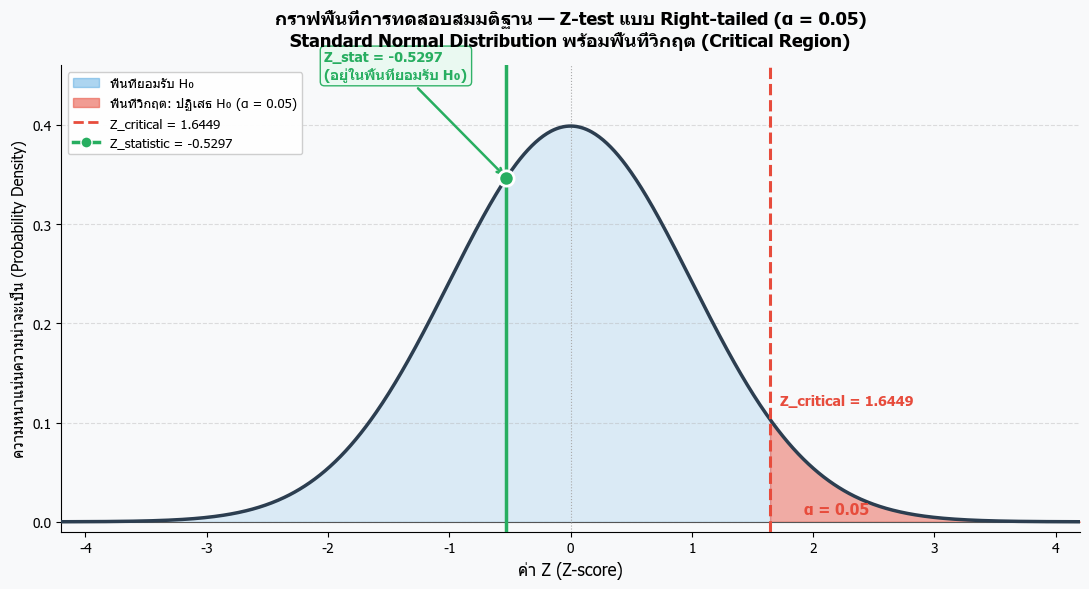

บันทึกกราฟเป็น graph_rejection_region.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

# --- Standard Normal Curve ---
x = np.linspace(-4.2, 4.2, 800)
y = stats.norm.pdf(x)
ax.plot(x, y, color='#2C3E50', linewidth=2.5, zorder=3)

# --- พื้นที่ยอมรับ H₀ (Acceptance Region) ---
x_acc = np.linspace(-4.2, z_crit, 400)
ax.fill_between(x_acc, stats.norm.pdf(x_acc),
                color='#3498DB', alpha=0.15, label='พื้นที่ยอมรับ H₀')

# --- พื้นที่วิกฤต (Critical Region / Rejection Region) ---
x_rej = np.linspace(z_crit, 4.2, 300)
ax.fill_between(x_rej, stats.norm.pdf(x_rej),
                color='#E74C3C', alpha=0.45, label=f'พื้นที่วิกฤต (α = {ALPHA})')

# --- เส้น Z-critical ---
ax.axvline(z_crit, color='#E74C3C', linewidth=2.2, linestyle='--', zorder=4)
ax.text(z_crit + 0.08, stats.norm.pdf(z_crit) + 0.012,
        f'Z_critical = {z_crit:.4f}',
        color='#E74C3C', fontsize=10, fontweight='bold', va='bottom')

# --- เส้นและจุด Z-statistic ---
ax.axvline(z_stat, color='#27AE60', linewidth=2.5, linestyle='-', zorder=5)
ax.plot(z_stat, stats.norm.pdf(z_stat),
        marker='o', markersize=11, color='#27AE60',
        markeredgecolor='white', markeredgewidth=2, zorder=6)

# ป้าย Z-statistic (อยู่ด้านซ้าย ชี้ว่าอยู่ในพื้นที่ยอมรับ)
ax.annotate(
    f'Z_stat = {z_stat:.4f}\n(อยู่ในพื้นที่ยอมรับ H₀)',
    xy=(z_stat, stats.norm.pdf(z_stat)),
    xytext=(z_stat - 1.5, stats.norm.pdf(z_stat) + 0.10),
    arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.8),
    fontsize=10, color='#27AE60', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#EAFAF1',
              edgecolor='#27AE60', alpha=0.95)
)

# --- ป้าย α บนพื้นที่วิกฤต ---
ax.text(z_crit + 0.55, 0.008, f'α = {ALPHA}',
        color='#E74C3C', fontsize=11, fontweight='bold', ha='center')

# --- แกนและตกแต่ง ---
ax.axhline(0, color='#555555', linewidth=0.8)
ax.axvline(0, color='#AAAAAA', linewidth=0.8, linestyle=':')
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-0.01, 0.46)
ax.set_xlabel('ค่า Z (Z-score)', fontsize=12)
ax.set_ylabel('ความหนาแน่นความน่าจะเป็น (Probability Density)', fontsize=11)
ax.set_title(
    'กราฟพื้นที่การทดสอบสมมติฐาน — Z-test แบบ Right-tailed (α = 0.05)\n'
    'Standard Normal Distribution พร้อมพื้นที่วิกฤต (Critical Region)',
    fontsize=13, fontweight='bold', pad=14
)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- Legend ---
legend_handles = [
    mpatches.Patch(color='#3498DB', alpha=0.4,  label='พื้นที่ยอมรับ H₀'),
    mpatches.Patch(color='#E74C3C', alpha=0.55, label=f'พื้นที่วิกฤต: ปฏิเสธ H₀ (α = {ALPHA})'),
    plt.Line2D([0], [0], color='#E74C3C', lw=2, linestyle='--',
               label=f'Z_critical = {z_crit:.4f}'),
    plt.Line2D([0], [0], color='#27AE60', lw=2.5, marker='o', markersize=8,
               markeredgecolor='white', label=f'Z_statistic = {z_stat:.4f}'),
]
ax.legend(handles=legend_handles, fontsize=9.5, loc='upper left',
          framealpha=0.95, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('graph_rejection_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('บันทึกกราฟเป็น graph_rejection_region.png')

---
## ขั้นตอนที่ 6 — สรุปผลการวิเคราะห์และแปลผลทางสถิติ

### 6.1 สถิติเชิงพรรณนา

| กลุ่ม | N | Mean (บาท) | SD (บาท) |
|---|:---:|---:|---:|
| A: ส่วนใหญ่เป็นเจ้าของที่ดิน | 76 | 27,442.09 | 14,169.63 |
| B: ส่วนใหญ่เช่าที่ดิน/ทำฟรี | 63 | 29,189.30 | 22,783.52 |

### 6.2 ผลการทดสอบสมมติฐาน

| พารามิเตอร์ | ค่า |
|---|---|
| Z-statistic | −0.5297 |
| Z-critical (α = 0.05, Right-tailed) | 1.6449 |
| เกณฑ์ตัดสิน | ปฏิเสธ H₀ ถ้า Z > 1.6449 |
| ผลการทดสอบ | **ไม่ปฏิเสธ H₀** |

### 6.3 สรุปและแปลผล

จากการวิเคราะห์ข้อมูลรายได้ประจำของครัวเรือนเกษตรกร 2 กลุ่ม ซึ่งมาจากฐานข้อมูลสำนักงานสถิติแห่งชาติ โดยใช้การทดสอบสมมติฐานแบบ Two-Sample Z-test ทิศทางเดียวด้านขวา (Right-tailed) ที่ระดับนัยสำคัญ α = 0.05 พบว่า

ค่าสถิติทดสอบ (Z-statistic) ที่คำนวณได้เท่ากับ **−0.5297** ซึ่ง**น้อยกว่า**ค่าวิกฤต (Z-critical) ที่ **1.6449** กล่าวคือ ค่า Z ที่ได้ตกอยู่ใน**พื้นที่ยอมรับ H₀** (Acceptance Region) ไม่ได้อยู่ในพื้นที่วิกฤต (Critical Region) ดังนั้น จึง**ไม่สามารถปฏิเสธสมมติฐาน (H₀) ได้** ที่ระดับนัยสำคัญ 0.05

สรุปได้ว่า **ไม่มีหลักฐานเพียงพอทางสถิติที่จะสรุปว่า รายได้ประจำเฉลี่ยของครัวเรือนเกษตรกรที่ส่วนใหญ่เป็นเจ้าของที่ดิน (กลุ่ม A, $\bar{x}_1$ = 27,442.09 บาท) สูงกว่ารายได้ประจำเฉลี่ยของครัวเรือนเกษตรกรที่ส่วนใหญ่เช่าที่ดิน/ทำฟรี (กลุ่ม B, $\bar{x}_2$ = 29,189.30 บาท)** ที่ระดับนัยสำคัญ 0.05

นอกจากนี้ ค่า Z-statistic ที่ได้มีเครื่องหมายเป็นลบ (−0.5297) แสดงว่าค่าเฉลี่ยของกลุ่ม A ต่ำกว่ากลุ่ม B จริง ซึ่งมีทิศทางตรงข้ามกับสมมติฐานทางเลือก H₁ ประกอบกับกลุ่ม B มีส่วนเบี่ยงเบนมาตรฐานสูงกว่ามาก (SD = 22,783.52 บาท เทียบกับ SD = 14,169.63 บาท) อาจสะท้อนให้เห็นว่าในกลุ่มเกษตรกรผู้เช่าที่ดินมีความเหลื่อมล้ำของรายได้ภายในกลุ่มสูง จึงทำให้ผลการทดสอบไม่มีนัยสำคัญ

ข้อมูลเป็นรายได้อย่างเดียวไม่ใช้กำไรที่ได้กลุ่มB เลยยังไม่หักจากต้นทุนค่าเช่าที่
ค่าZ ติดลบจากการตั้งสมมติฐาน เป็น A>B จุดวิกฤตจึงอยู่ฟังบวก แต่จากข้อมูลที่มี รายได้เฉลี่ยของกลุ่มB มีรายได้มากกว่า